## $^{137}Cs$ preprod @ 4.2 bar

* Check the efficiencie for the $^{137}Cs$
* Check the energy spectra

In [1]:
import pandas as pd
import tables as tb
import glob
import numpy as np
from invisible_cities.io.dst_io import load_dst

import matplotlib.pyplot as plt

In [2]:
path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/final_LPR/{isotope}/'
file_path = path + 'prod/{port}/nexus/*.h5'

In [3]:
# NUMBER OF SIMULATED EVENTS
nevent_per_file = 10000
nfiles_per_port = 10
nevents_per_port = nevent_per_file * nfiles_per_port
nport = 4
nevents = nevents_per_port * nport

In [4]:
def get_mc_info(f):
    hit_df = load_dst(f, 'MC', 'hits')
    conf_df = load_dst(f, 'MC', 'configuration')
    hit_df = hit_df.merge(hit_df.groupby('event_id').energy.sum().rename('tot_ene'), on='event_id')
    hit_df = hit_df.merge(hit_df.groupby('event_id').size().rename('nhits'), on='event_id')
    hit_df_ = hit_df[['event_id', 'tot_ene', 'nhits']].drop_duplicates()

    hit_df_['port'] = conf_df[conf_df.param_key == '/Generator/IonGenerator/region'].param_value.values[0].replace(' ', '')
    return hit_df_

## $^{137}Cs$

In [5]:
isotope = '137Cs'

In [6]:
# sim_evs_137Cs = pd.DataFrame([{'sim_evs_per_file': nevent_per_file, 'sim_files_per_port': nfiles_per_port, 'n_ports':nport}])

# info_df_137Cs = pd.DataFrame()
# for f in sorted(glob.glob(file_path.format(isotope=isotope, port='*')), key = lambda x: (x.split('/')[-3], int(x.split('_')[-2]))):
#     info_df_137Cs = info_df_137Cs.append(get_mc_info(f))

save_path_137Cs = path.format(isotope=isotope) + '/summary_137Cs.h4'
# info_df_137Cs.to_hdf(save_path_137Cs, key = 'events_info') 
# sim_evs_137Cs.to_hdf(save_path_137Cs, key = 'sim_info') 

In [7]:
info_df_137Cs = pd.read_hdf(save_path_137Cs, 'events_info')
sim_evs_137Cs = pd.read_hdf(save_path_137Cs, 'sim_info')

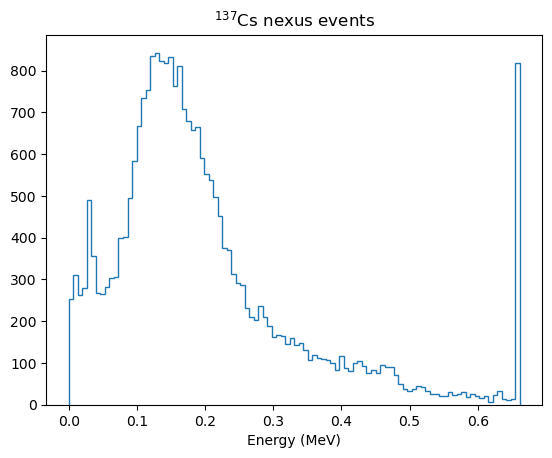

In [8]:
plt.hist(info_df_137Cs.tot_ene, 100, histtype='step')
plt.xlabel('Energy (MeV)')
plt.title('$^{137}$Cs nexus events')
# plt.yscale('log')
plt.show()

We can clearly see:

* Photopeak    @ 0.6617 MeV
* Compton edge @ 0.4773 MeV
* Compton peak @ 0.1843 MeV
* 137Ba X-rays @ 0.0320 MeV

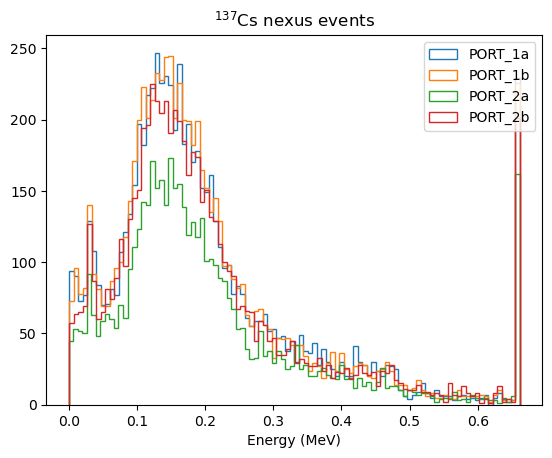

In [9]:
for port in info_df_137Cs.port.unique():
    plt.hist(info_df_137Cs[info_df_137Cs.port == port].tot_ene, 100, histtype = 'step', label = port)
plt.xlabel('Energy (MeV)')
plt.title('$^{137}$Cs nexus events')
plt.legend()
plt.show()

In [10]:
info_df_137Cs

,event_id,tot_ene,nhits,port
0,0,0.088016,25,PORT_1a
25,1,0.012106,15,PORT_1a
40,2,0.130738,60,PORT_1a
100,3,0.328382,131,PORT_1a
231,4,0.298527,103,PORT_1a
...,...,...,...,...
61579,90646,0.164272,62,PORT_2b
61641,90647,0.420991,137,PORT_2b
61778,90648,0.431307,177,PORT_2b
61955,90649,0.661657,268,PORT_2b


In [39]:
size_path = path.format(isotope=isotope) + '/size_data_compr.txt'
size_order = 'M'
with open(size_path, 'r') as f:
        text = f.readlines()
        f.close()
folder_size = [[isotope, t.split("\t")[1].split('/')[0].rstrip('\n'),float(t.split("\t")[0].rstrip(size_order).replace(',', '.'))] for t in text[:-1]]
size_df = pd.DataFrame(folder_size, columns = ['isotope', 'port', 'size'])

In [40]:
size_df

,isotope,port,size
0,137Cs,PORT_1a,19.0
1,137Cs,PORT_1b,19.0
2,137Cs,PORT_2a,13.0
3,137Cs,PORT_2b,17.0


In [41]:
def print_effs_and_sim(df, isotope, size_df, e_threshold = (0, np.inf), nevents_per_port = 5e4, nevents = 2e5, desired_events = 1e6, round_factor = 1e5, target_evs_file = 2e4):
    df = df[(df.tot_ene > e_threshold[0]) & (df.tot_ene < e_threshold[1])]
    size_df = size_df[size_df.isotope == isotope].drop(columns='isotope').set_index('port')['size']
    port_eff = df.groupby('port').size() / nevents_per_port

    print('MC efficiencies ({} < E < {})'.format(e_threshold[0], e_threshold[1]))
    print('Each port:')
    print(port_eff)
    print('')

    print('Total efficiency')
    print(len(df) / nevents)

    print('')
    print('In each port we will need to simulate (to have at least {} events):'.format(desired_events))
    print(desired_events / port_eff)

    print('')
    print('Which we can set up to:')
    target_evs_port = np.ceil((desired_events / port_eff).max() / round_factor) * round_factor
    print(target_evs_port, ' events per port')
    print(target_evs_port / target_evs_file, ' tasks/files per port if we simulate ', target_evs_file, ' events per file')
    print('With the current eff, these files will have around ', target_evs_file * port_eff.mean(), ' events per file')
    print('')
    print('For having {}, we expect that the production will occupy:'.format(desired_events))
    expected_size = size_df / df.groupby('port').size() * desired_events
    print(expected_size)
    print('In total: {} M'.format(expected_size.sum()))
    return port_eff, expected_size

In [42]:
port_eff, expected_size = print_effs_and_sim(info_df_137Cs, 
                                            isotope, 
                                            size_df, 
                                            e_threshold = (0, np.inf), 
                                            nevents_per_port = nevents_per_port, 
                                            nevents = nevents, 
                                            desired_events = 1e6, 
                                            round_factor = 1e5, 
                                            target_evs_file = 3e4)


MC efficiencies (0 < E < inf)
Each port:
port
PORT_1a    0.07156
PORT_1b    0.07290
PORT_2a    0.04981
PORT_2b    0.06598
dtype: float64

Total efficiency
0.0650625

In each port we will need to simulate (to have at least 1000000.0 events):
port
PORT_1a    1.397429e+07
PORT_1b    1.371742e+07
PORT_2a    2.007629e+07
PORT_2b    1.515611e+07
dtype: float64

Which we can set up to:
20100000.0  events per port
670.0  tasks/files per port if we simulate  30000.0  events per file
With the current eff, these files will have around  1951.8749999999998  events per file

For having 1000000.0, we expect that the production will occupy:
port
PORT_1a    2655.114589
PORT_1b    2606.310014
PORT_2a    2609.917687
PORT_2b    2576.538345
dtype: float64
In total: 10447.880635037794 M


In [43]:
port_eff, expected_size = print_effs_and_sim(info_df_137Cs, 
                                            isotope, 
                                            size_df, 
                                            e_threshold = (0.65, np.inf), 
                                            nevents_per_port = nevents_per_port, 
                                            nevents = nevents, 
                                            desired_events = 1e6, 
                                            round_factor = 1e5, 
                                            target_evs_file = 3e4)

MC efficiencies (0.65 < E < inf)
Each port:
port
PORT_1a    0.00232
PORT_1b    0.00229
PORT_2a    0.00166
PORT_2b    0.00202
dtype: float64

Total efficiency
0.0020725

In each port we will need to simulate (to have at least 1000000.0 events):
port
PORT_1a    4.310345e+08
PORT_1b    4.366812e+08
PORT_2a    6.024096e+08
PORT_2b    4.950495e+08
dtype: float64

Which we can set up to:
602500000.0  events per port
20083.333333333332  tasks/files per port if we simulate  30000.0  events per file
With the current eff, these files will have around  62.17499999999999  events per file

For having 1000000.0, we expect that the production will occupy:
port
PORT_1a    81896.551724
PORT_1b    82969.432314
PORT_2a    78313.253012
PORT_2b    84158.415842
dtype: float64
In total: 327337.6528921808 M


#### Plot an scheme of the detector with the efficiencies

In [58]:
# Cylinder surface parameters
radius = 67.555
zmin = -84
zmax = +84
resolution = 200  # Number of points to approximate the cylinder's surface

def cylinder_surface(rad, zmin, zmax, resol):
    # Create points for the cylinder's surface
    theta = np.linspace(0, 2 * np.pi, resol)
    z = np.linspace(zmin, zmax, resol)
    Theta, Z = np.meshgrid(theta, z)
    X = rad * np.cos(Theta)
    Y = rad * np.sin(Theta)
    return X, Y, Z

# Ports of the cylinder
port_x = ( 47.77, -47.77, 47.477, -47.77)
port_y = ( 47.77, 47.477,  47.77,  47.77)
port_z = (-13.95, -30.79,  45.05,  19.21)
port_n = ('PORT_1a', 'PORT_1b', 'PORT_2a', 'PORT_2b')
port_info = [port_x, port_y, port_z, port_n]

# Eff for each port in a energy range
e_range = (0, np.inf) #(0.65, 0.67)
desired_events = 1e5

port_eff_137Cs, exp_size_137Cs = print_effs_and_sim(info_df_137Cs, 
                                                    isotope, 
                                                    size_df, 
                                                    e_threshold = e_range, 
                                                    nevents_per_port = nevents_per_port, 
                                                    nevents = nevents, 
                                                    desired_events = desired_events, 
                                                    round_factor = 1e5, 
                                                    target_evs_file = 3e4)

MC efficiencies (0 < E < inf)
Each port:
port
PORT_1a    0.07156
PORT_1b    0.07290
PORT_2a    0.04981
PORT_2b    0.06598
dtype: float64

Total efficiency
0.0650625

In each port we will need to simulate (to have at least 100000.0 events):
port
PORT_1a    1.397429e+06
PORT_1b    1.371742e+06
PORT_2a    2.007629e+06
PORT_2b    1.515611e+06
dtype: float64

Which we can set up to:
2100000.0  events per port
70.0  tasks/files per port if we simulate  30000.0  events per file
With the current eff, these files will have around  1951.8749999999998  events per file

For having 100000.0, we expect that the production will occupy:
port
PORT_1a    265.511459
PORT_1b    260.631001
PORT_2a    260.991769
PORT_2b    257.653834
dtype: float64
In total: 1044.7880635037793 M


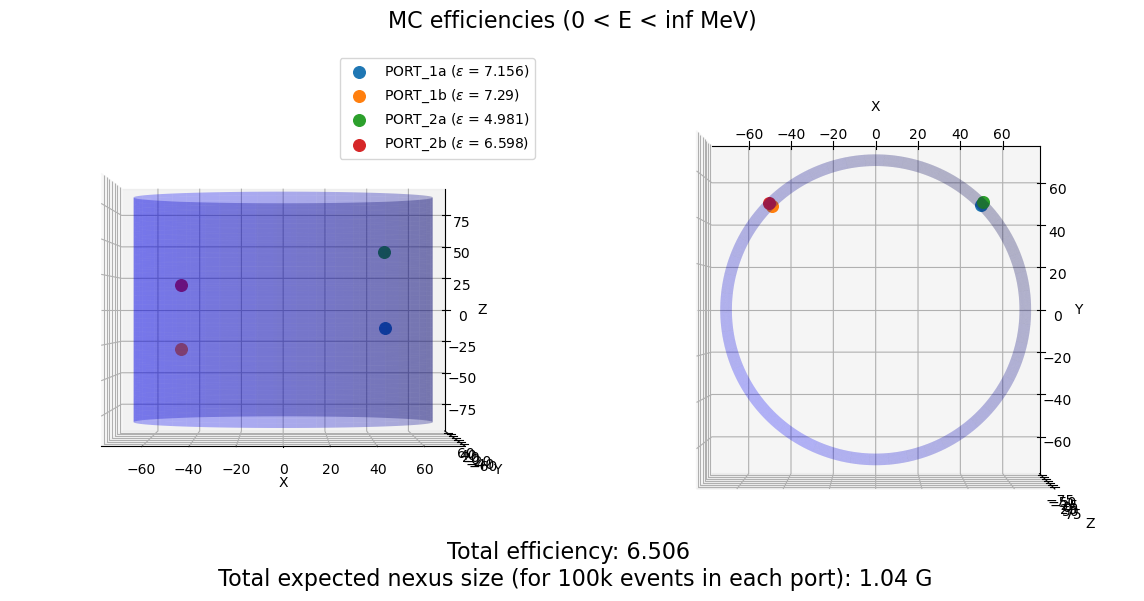

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize = (12, 6))

cyl_surf = cylinder_surface(radius, zmin, zmax, resolution)

def plot_next100_scheme(fig, subplot, cyl_surf, port_info, port_eff, ang = (0, 0)):
    # Create a 3D figure
    
    ax = fig.add_subplot(subplot, projection='3d')

    # Plot the surface of the cylinder
    X, Y, Z = cyl_surf[0], cyl_surf[1], cyl_surf[2]
    ax.plot_surface(X, Y, Z, color='b', alpha= 0.3)

    # Plot the ports of the cylinder
    port_x, port_y, port_z, port_n = port_info
    for x, y, z, n in zip(port_x, port_y, port_z, port_n):
        ax.scatter(x, y, z, marker='o', s=70, label=n + ' ($\epsilon$ = {:.4})'.format(port_eff[n] * 100))
    
    # Set axis labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=ang[0], azim=ang[1]) 
    return ax

plt.suptitle('MC efficiencies ({} < E < {} MeV)'.format(e_range[0], e_range[1]), fontsize=16)
fig.text(0.5, 0.02, 'Total efficiency: {:.4} \n Total expected nexus size (for {}k events in each port): {:.3} G'.format(port_eff_137Cs.mean() * 100, int(desired_events / 1000), exp_size_137Cs.sum() / 1000), ha='center', fontsize=16)
ax = plot_next100_scheme(fig, 121, cyl_surf, port_info, port_eff_137Cs, ang=(0, -90))
ax.legend()
ax = plot_next100_scheme(fig, 122, cyl_surf, port_info, port_eff_137Cs, ang=(90, 270))
plt.tight_layout()

# Show the plot
plt.show()

In [21]:
exp_size_137Cs

port
PORT_1a    2.116379e+06
PORT_1b    2.144105e+06
PORT_2a    2.819277e+06
PORT_2b    2.316832e+06
dtype: float64